## Step 1: Install Required Packages

Run this cell once. Package installation may take some time in Colab.


In [13]:
system("apt-get update -qq")
system("apt-get install -y libmagick++-dev")

install.packages(
  "magick",
  repos = "https://cloud.r-project.org"
)

install.packages(
  "keras3",
  repos = "https://cloud.r-project.org"
)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## Step 2: Configure Keras / TensorFlow

Run this cell if TensorFlow is not already available in your Colab R runtime.


In [14]:
library(magick)
library(keras3)

cat("magick loaded successfully!\n")
cat("keras3 loaded successfully!\n")

magick loaded successfully!
keras3 loaded successfully!


## Step 3: Upload the Dataset ZIP in Colab

In Google Colab, use the Files panel on the left and upload `images.zip`.

Then run the following cell to extract it.


In [15]:
unzip("images.zip", exdir = ".")

cat("Files extracted successfully.\n")


Files extracted successfully.


## Step 4: Check Dataset Files


In [16]:
image_dir <- "images"

files <- list.files(
  image_dir,
  pattern = "\\.(jpg|jpeg|png)$",
  full.names = TRUE,
  ignore.case = TRUE
)

cat("Total images found:", length(files), "\n")
print(head(files))


Total images found: 12 
[1] "images/c1.jpg" "images/c2.jpg" "images/c3.jpg" "images/c4.jpg"
[5] "images/c5.jpg" "images/c6.jpg"


## Step 5: Assign Labels

Images starting with `c` are treated as **Car**.

Images starting with `p` are treated as **Plane**.


In [17]:
get_label <- function(file) {
  name <- tolower(basename(file))

  if (startsWith(name, "c")) {
    return(0)
  } else if (startsWith(name, "p")) {
    return(1)
  } else {
    stop(
      paste(
        "Unknown filename:", name,
        "- filename must start with c or p"
      )
    )
  }
}

labels <- sapply(files, get_label)

cat("Cars:", sum(labels == 0), "\n")
cat("Planes:", sum(labels == 1), "\n")


Cars: 6 
Planes: 6 


## Step 6: Visualize Sample Images


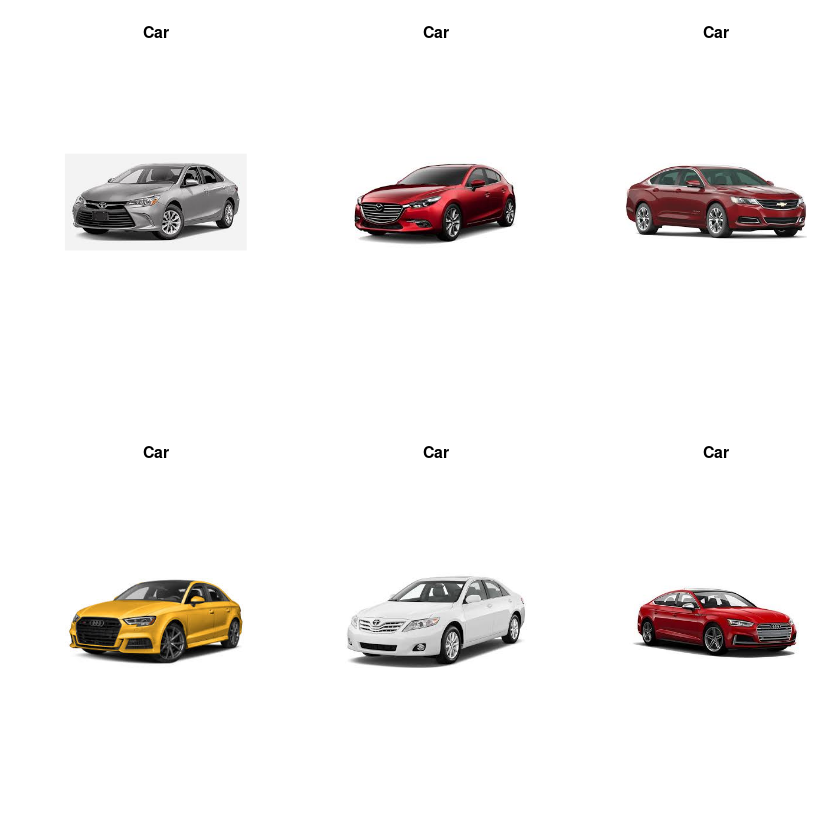

In [18]:
sample_files <- head(files, min(6, length(files)))

par(mfrow = c(2, 3))

for (f in sample_files) {

  img <- image_read(f)

  plot(img)

  label <- ifelse(
    get_label(f) == 0,
    "Car",
    "Plane"
  )

  title(main = label)
}

par(mfrow = c(1, 1))


## Step 7: Image Preprocessing

All images are:

- Converted to RGB
- Resized to 64 × 64 pixels
- Converted into numeric arrays
- Normalized to the range 0–1


In [19]:
IMG_HEIGHT <- 64
IMG_WIDTH <- 64
CHANNELS <- 3

load_image_array <- function(path) {

  img <- image_read(path)

  img <- image_convert(
    img,
    colorspace = "sRGB"
  )

  img <- image_resize(
    img,
    paste0(
      IMG_WIDTH,
      "x",
      IMG_HEIGHT,
      "!"
    )
  )

  arr <- as.integer(img[[1]])

  arr <- aperm(
    arr,
    c(2, 3, 1)
  )

  if (dim(arr)[3] > 3) {
    arr <- arr[, , 1:3]
  }

  arr <- arr / 255

  return(arr)
}


## Step 8: Convert All Images into a Tensor


In [24]:
# STEP 8: Convert all images into tensor + create labels

images_list <- lapply(
  files,
  load_image_array
)

cat("Total processed images:", length(images_list), "\n")

# Create input tensor
X <- array(
  0,
  dim = c(
    length(images_list),
    IMG_HEIGHT,
    IMG_WIDTH,
    CHANNELS
  )
)

for (i in seq_along(images_list)) {

  X[i, , , ] <- images_list[[i]]

}

# Create labels
# 0 = Car
# 1 = Plane
y <- as.numeric(labels)

# Display details
cat(
  "Input tensor shape:",
  paste(dim(X), collapse = " x "),
  "\n"
)

cat(
  "Number of labels:",
  length(y),
  "\n"
)

cat(
  "Labels:",
  y,
  "\n"
)

Total processed images: 12 
Input tensor shape: 12 x 64 x 64 x 3 
Number of labels: 12 
Labels: 0 0 0 0 0 0 1 1 1 1 1 1 


## Step 9: Shuffle and Split Dataset

80% of the images are used for training and 20% for testing.


In [25]:
set.seed(123)

indices <- sample(seq_len(dim(X)[1]))

X <- X[
  indices,
  ,
  ,
  ,
  drop = FALSE
]

y <- y[indices]

train_size <- floor(
  0.80 * length(y)
)

train_idx <- seq_len(train_size)

test_idx <- (
  train_size + 1
):length(y)

x_train <- X[
  train_idx,
  ,
  ,
  ,
  drop = FALSE
]

y_train <- y[train_idx]

x_test <- X[
  test_idx,
  ,
  ,
  ,
  drop = FALSE
]

y_test <- y[test_idx]

cat(
  "Training samples:",
  length(y_train),
  "\n"
)

cat(
  "Testing samples:",
  length(y_test),
  "\n"
)


Training samples: 9 
Testing samples: 3 


## Step 10: Build the CNN Model

Architecture:

- Conv2D (32 filters)
- MaxPooling
- Conv2D (64 filters)
- MaxPooling
- Conv2D (128 filters)
- MaxPooling
- Flatten
- Dense (128)
- Dropout
- Sigmoid output


In [26]:
model <- keras_model_sequential() |>

  layer_conv_2d(
    filters = 32,
    kernel_size = c(3, 3),
    activation = "relu",
    input_shape = c(
      IMG_HEIGHT,
      IMG_WIDTH,
      CHANNELS
    )
  ) |>

  layer_max_pooling_2d(
    pool_size = c(2, 2)
  ) |>

  layer_conv_2d(
    filters = 64,
    kernel_size = c(3, 3),
    activation = "relu"
  ) |>

  layer_max_pooling_2d(
    pool_size = c(2, 2)
  ) |>

  layer_conv_2d(
    filters = 128,
    kernel_size = c(3, 3),
    activation = "relu"
  ) |>

  layer_max_pooling_2d(
    pool_size = c(2, 2)
  ) |>

  layer_flatten() |>

  layer_dense(
    units = 128,
    activation = "relu"
  ) |>

  layer_dropout(
    rate = 0.5
  ) |>

  layer_dense(
    units = 1,
    activation = "sigmoid"
  )

summary(model)


Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                   │ (None, 62, 62, 32)       │           896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)      │ (None, 31, 31, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)                 │ (None, 29, 29, 64)       │        18,496 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)    │ (None, 14, 14, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)                 │ (None, 12, 12, 128)      │        73,856 │
├───────

## Step 11: Compile the Model


In [27]:
model |> compile(
  optimizer = "adam",
  loss = "binary_crossentropy",
  metrics = c("accuracy")
)


## Step 12: Train the CNN


In [28]:
history <- model |> fit(

  x_train,
  y_train,

  epochs = 20,

  batch_size = 4,

  validation_split = 0.20,

  verbose = 2
)


## Step 13: Plot Training History


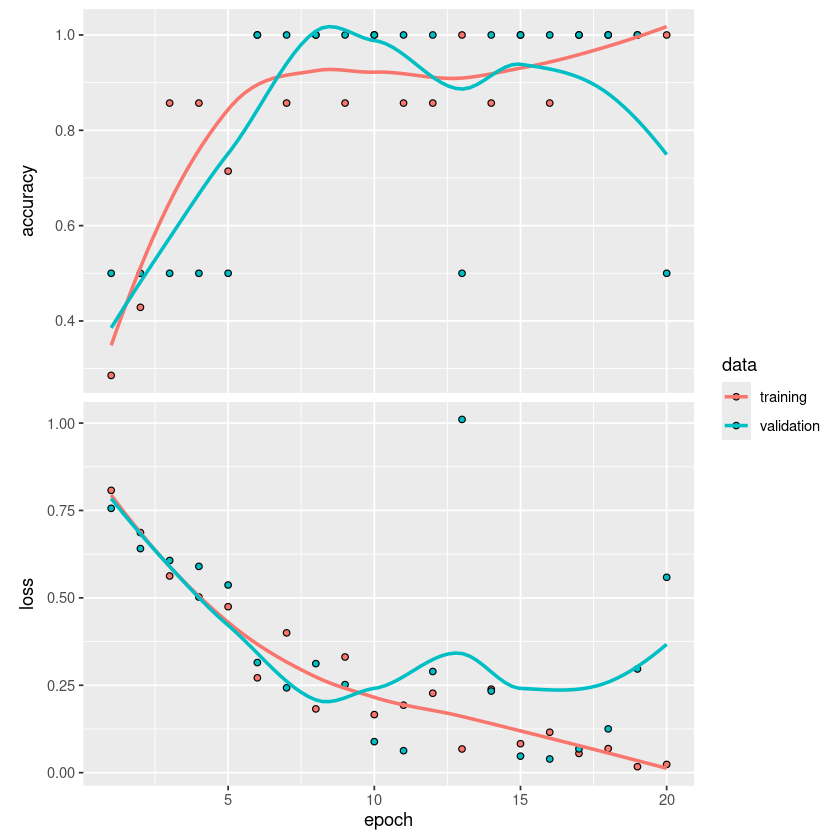

In [29]:
plot(history)


## Step 14: Evaluate the Model


In [31]:
results <- model |> evaluate(
  x_test,
  y_test,
  verbose = 0
)

test_loss <- as.numeric(results$loss)
test_accuracy <- as.numeric(results$accuracy)

cat("Test Loss:", round(test_loss, 4), "\n")
cat("Test Accuracy:", round(test_accuracy * 100, 2), "%\n")

Test Loss: 0.5279 
Test Accuracy: 66.67 %


## Step 15: Generate Predictions


In [32]:
probabilities <- as.numeric(
  model |> predict(
    x_test,
    verbose = 0
  )
)

predicted <- ifelse(
  probabilities >= 0.5,
  1,
  0
)

class_names <- c(
  "Car",
  "Plane"
)

prediction_table <- data.frame(

  Actual =
    class_names[y_test + 1],

  Predicted =
    class_names[predicted + 1],

  Confidence =
    round(
      ifelse(
        predicted == 1,
        probabilities,
        1 - probabilities
      ) * 100,
      2
    )
)

print(prediction_table)


  Actual Predicted Confidence
1  Plane       Car      77.10
2    Car       Car      99.98
3  Plane     Plane      89.64


## Step 16: Confusion Matrix


In [33]:
cm <- table(

  Actual =
    class_names[y_test + 1],

  Predicted =
    class_names[predicted + 1]
)

cat(
  "Confusion Matrix:\n"
)

print(cm)


Confusion Matrix:
       Predicted
Actual  Car Plane
  Car     1     0
  Plane   1     1


## Step 17: Calculate Accuracy Manually


In [34]:
manual_accuracy <- mean(
  predicted == y_test
)

cat(
  "Classification Accuracy:",
  round(
    manual_accuracy * 100,
    2
  ),
  "%\n"
)


Classification Accuracy: 66.67 %


## Step 18: Save the Trained Model


In [35]:
save_model(
  model,
  "car_plane_classifier.keras"
)

cat(
  "Model saved successfully as car_plane_classifier.keras\n"
)


Model saved successfully as car_plane_classifier.keras


## Step 19: Predict a New Image

Change `new_image_path` to the path of any uploaded car or plane image.


In [36]:
predict_image <- function(
  image_path,
  model
) {

  img <- image_read(
    image_path
  )

  img <- image_convert(
    img,
    colorspace = "sRGB"
  )

  img <- image_resize(
    img,
    paste0(
      IMG_WIDTH,
      "x",
      IMG_HEIGHT,
      "!"
    )
  )

  arr <- as.integer(
    img[[1]]
  )

  arr <- aperm(
    arr,
    c(2, 3, 1)
  )

  if (dim(arr)[3] > 3) {
    arr <- arr[, , 1:3]
  }

  arr <- arr / 255

  input <- array(
    arr,
    dim = c(
      1,
      IMG_HEIGHT,
      IMG_WIDTH,
      3
    )
  )

  probability <- as.numeric(
    model |> predict(
      input,
      verbose = 0
    )
  )

  if (probability >= 0.5) {

    predicted_class <- "Plane"

    confidence <-
      probability * 100

  } else {

    predicted_class <- "Car"

    confidence <-
      (1 - probability) * 100
  }

  cat(
    "Predicted Class:",
    predicted_class,
    "\n"
  )

  cat(
    "Confidence:",
    round(
      confidence,
      2
    ),
    "%\n"
  )
}

# Example:
# predict_image(
#   "images/c1.jpg",
#   model
# )


# Conclusion

A CNN-based binary image-classification system was implemented in R using Keras and TensorFlow.

The model preprocesses images, extracts visual features using convolutional layers, classifies them as **Car** or **Plane**, evaluates performance on test images, generates a confusion matrix, and supports prediction on new images.

> Note: If the dataset contains only a small number of images, the model is suitable mainly for demonstration or laboratory purposes. A larger dataset is required for reliable real-world performance.
